## ============================================================================
## Setup
## ============================================================================

In [110]:
### ~~~ GLOBAL IMPORTS ~~~ ###
from ucimlrepo import fetch_ucirepo
from dataclasses import dataclass
import matplotlib.pyplot as plt
from tqdm import trange
from functools import reduce
import seaborn as sns
from enum import Enum
import pandas as pd
import numpy as np

### ~~~ TYPE DEFINITIONS ~~~ ###
from typing import Callable, TypeAlias, Any

tensor_t: TypeAlias = np.ndarray
dim_t: TypeAlias = tuple[int, ...]
callback_t: TypeAlias = Callable[["State"], None]
optimiser_t: TypeAlias = Callable[["Model", list["Gradients"]], None]

In [3]:
class FeatureSelectionMethod(str, Enum):
    CORRELATION = "correlation"
    MUTUAL_INFORMATION = "mutual_information"


class ActivationFunction(str, Enum):
    RELU = "relu"
    SIGMOID = "sigmoid"
    TANH = "tanh"
    LINEAR = "linear"


class LossFunction(str, Enum):
    BCE = "binary_cross_entropy"
    MSE = "mean_squared_error"


class AccuracyMetric(str, Enum):
    BINARY_ACCURACY = "binary_accuracy"


@dataclass
class Layer:
    name: str
    input_dim: dim_t
    output_dim: dim_t
    activation: ActivationFunction
    weights: tensor_t
    bias: tensor_t
    x: tensor_t | None
    z: tensor_t | None


@dataclass
class Gradients:
    dW: tensor_t
    db: tensor_t


@dataclass
class Model:
    layers: list[Layer]
    loss_function: LossFunction
    learning_rate: float
    accuracy_function: AccuracyMetric = AccuracyMetric.BINARY_ACCURACY


@dataclass
class History:
    train_loss: list[float]
    val_loss: list[float]
    train_accuracy: list[float]
    val_accuracy: list[float]


@dataclass
class State:
    epoch: int
    model: Any
    history: History
    train_loss: float
    val_loss: float
    stop_training: bool = False

In [16]:
### ~~~ STATE MANAGEMENT ~~~ ###
TARGET_COLUMN: str = "target"
RANDOM_SEED: int = 42
RATIOS: dict[str, float] = {
    "train": 0.7,
    "validation": 0.15,
    "test": 0.15,
}
BATCH_SIZE: int = 320
EPOCHS: int = 1000
LEARNING_RATE: float = 0.01

RNG = np.random.default_rng(RANDOM_SEED)
sns.set(style="whitegrid")
FIG_SIZE = (12, 8)

## ============================================================================
## SECTION I
## ============================================================================

In [32]:
def load_data(from_cache: bool = False) -> pd.DataFrame:
    """
    Dataset Selection: Diabetes Health Indicators Dataset
    Args:
        None
    Returns:
        pd.DataFrame: The breast cancer dataset with features and target.
    """
    ### load up the data ###
    if from_cache:
        data = pd.read_csv("dbs/diabetes.csv")
        df = pd.DataFrame(data)
        df.rename(columns={"Diabetes_binary": TARGET_COLUMN}, inplace=True)
    else:
        data = fetch_ucirepo(id=891).data

        ### put it into a df ###
        df = pd.DataFrame(data.features)

        ### add the target ###
        df[TARGET_COLUMN] = data.targets

    return df


In [33]:
df = load_data()


print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())
print(f"\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts())

Dataset shape: (253680, 22)

First few rows:
   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  NoDocbcCost  GenHlth  MentHlth  \
0             0       0        1  ...            0        5        18   
1             1       0        0  ...            1        3         0   
2             0       1        0  ...            1        5        30   
3             1       1        1  ...            0        2         0   
4             1       1        1  ...            0        2         3   

   PhysHlth  DiffWalk  Sex  Age  Education  Income  t

## ============================================================================
## SECTION II
## ============================================================================

### Part I

In [12]:
def show_feature_summary(df: pd.DataFrame) -> None:
    """
    1. Feature Identification & Summary (Req. 2.1)
        - Generates a detailed summary table for all features, including:
          data types, total/unique values, missing values, sample values,
          min/max, mean, median, variance, and standard deviation.
        - Prints the summary to the console.
    Args:
        df : pd.DataFrame
            The raw dataset.
    Returns:
        None
    """
    feature_summary = pd.DataFrame(
        {
            "Feature": df.columns,
            "Data Type": [df[col].dtype for col in df.columns],
            "Total Values": [df[col].count() for col in df.columns],
            "Unique Values": [df[col].nunique() for col in df.columns],
            "Missing Values": [df[col].isnull().sum() for col in df.columns],
            "Sample Value": [df[col].iloc[0] for col in df.columns],
            "Min Value": [df[col].min() for col in df.columns],
            "Max Value": [df[col].max() for col in df.columns],
            "Mean": [df[col].mean() for col in df.columns],
            "Median": [df[col].median() for col in df.columns],
            "Std Dev": [df[col].std() for col in df.columns],
            "Variance": [df[col].var() for col in df.columns],
        }
    )

    ### some printing ###
    print("Enhanced Feature Summary Table:")
    print(feature_summary)

    return None

In [13]:
show_feature_summary(df)

Enhanced Feature Summary Table:
                 Feature Data Type  Total Values  Unique Values  \
0                 HighBP     int64        253680              2   
1               HighChol     int64        253680              2   
2              CholCheck     int64        253680              2   
3                    BMI     int64        253680             84   
4                 Smoker     int64        253680              2   
5                 Stroke     int64        253680              2   
6   HeartDiseaseorAttack     int64        253680              2   
7           PhysActivity     int64        253680              2   
8                 Fruits     int64        253680              2   
9                Veggies     int64        253680              2   
10     HvyAlcoholConsump     int64        253680              2   
11         AnyHealthcare     int64        253680              2   
12           NoDocbcCost     int64        253680              2   
13               GenHlth     i

### Part II

In [17]:
def show_visualizations(df: pd.DataFrame) -> None:
    """
    Generate and display visualizations for the dataset.
        - Histograms for all non-target features.
        - Scatter plots for the top 4 most correlated features against the target.
        - Box plots for the top 4 most correlated features grouped by target class.
        - Correlation heatmap using Pearson correlations.
        - Box plots of all numerical features to reveal distribution shape and outliers.
    Args:
        df : pd.DataFrame
            The raw dataset.
    Returns:
        None
    """
    ### drop the target for visualization purposes ###
    df_features = df.drop(columns="target")

    #### 1. Histograms for all features ####
    df_features.hist(
        bins=15, figsize=FIG_SIZE, layout=(6, 5), color="skyblue", edgecolor="black"
    )
    plt.suptitle("Feature Distributions", fontsize=20)
    plt.show()

    ### Select top 4 features based on correlation with target ###
    correlations = df.corr()["target"].abs().sort_values(ascending=False)
    top_4_features = correlations[1:5].index.tolist()

    ### 2. Scatter plots of top 4 features against the target ###
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_4_features):
        sns.scatterplot(
            data=df,
            x=feature,
            y="target",
            hue="target",
            ax=axes[i],
            palette={0: "red", 1: "green"},
            legend=False,
        )
        axes[i].set_title(f"Scatter: {feature} vs Target")
        axes[i].set_yticks([0, 1])

    plt.suptitle("Top 4 Correlated Features vs. Target Scatter Plots", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    ### 2.5 Box Plots of Top 4 Features by Target Class ###
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE)
    axes = axes.flatten()

    for i, feature in enumerate(top_4_features):
        sns.boxplot(x="target", y=feature, data=df, ax=axes[i])
        axes[i].set_title(f"Box Plot of {feature} by Target")

    plt.suptitle("Top 4 Correlated Features Box Plots by Target Class", fontsize=20)
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
    plt.show()

    ### 3. Correlation Heatmap ###
    plt.figure(figsize=FIG_SIZE)
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title("Correlation Heatmap of Features", fontsize=18)
    plt.show()

    ### 4. Box Plots for All Numeric Features ###
    ## Selecting numeric columns (all features except target) ##
    numerical_cols = df.drop(columns="target").columns
    n_plots = len(numerical_cols)  # total features
    n_cols = 5  # number of columns in grid
    n_rows = int(np.ceil(n_plots / n_cols))  # number of rows needed

    fig, axes = plt.subplots(n_rows, n_cols, figsize=FIG_SIZE)
    axes = axes.flatten()  # flatten for easy iteration

    ## Looping through each numeric feature and create boxplot ##
    for idx, col in enumerate(numerical_cols):
        axes[idx].boxplot(
            df[col].dropna(),
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="lightblue", alpha=0.7),
        )
        axes[idx].set_title(f"Box Plot: {col}", fontsize=10, fontweight="bold")
        axes[idx].set_ylabel(col, fontsize=9)
        axes[idx].grid(True, alpha=0.3, axis="y")

    ## Removing empty subplots if total plots < grid cells ##
    for idx in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[idx])

    ### Adjust layout and show ###
    plt.tight_layout()
    plt.show()

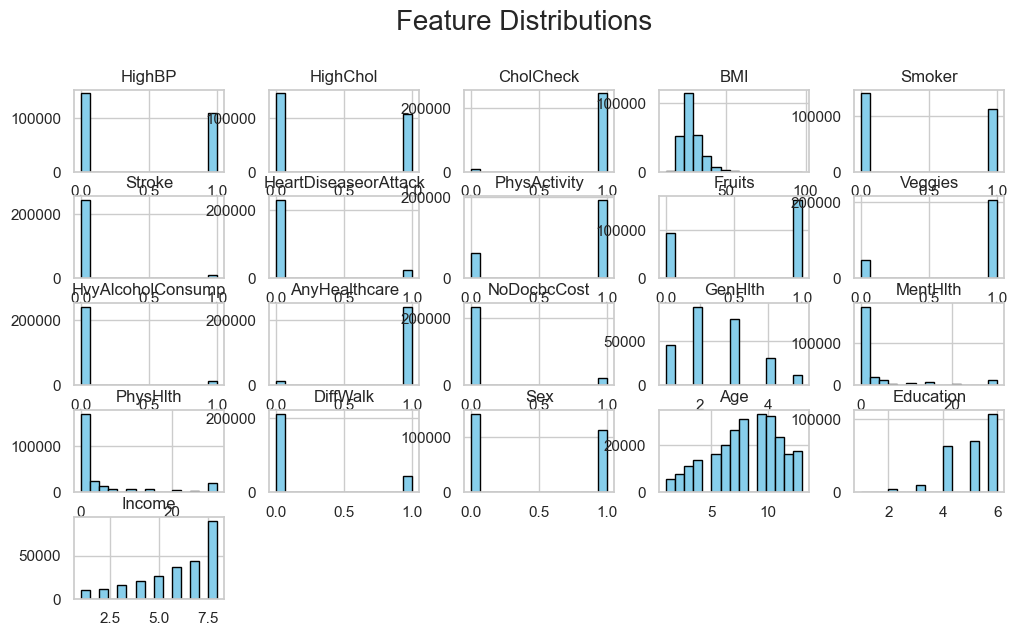

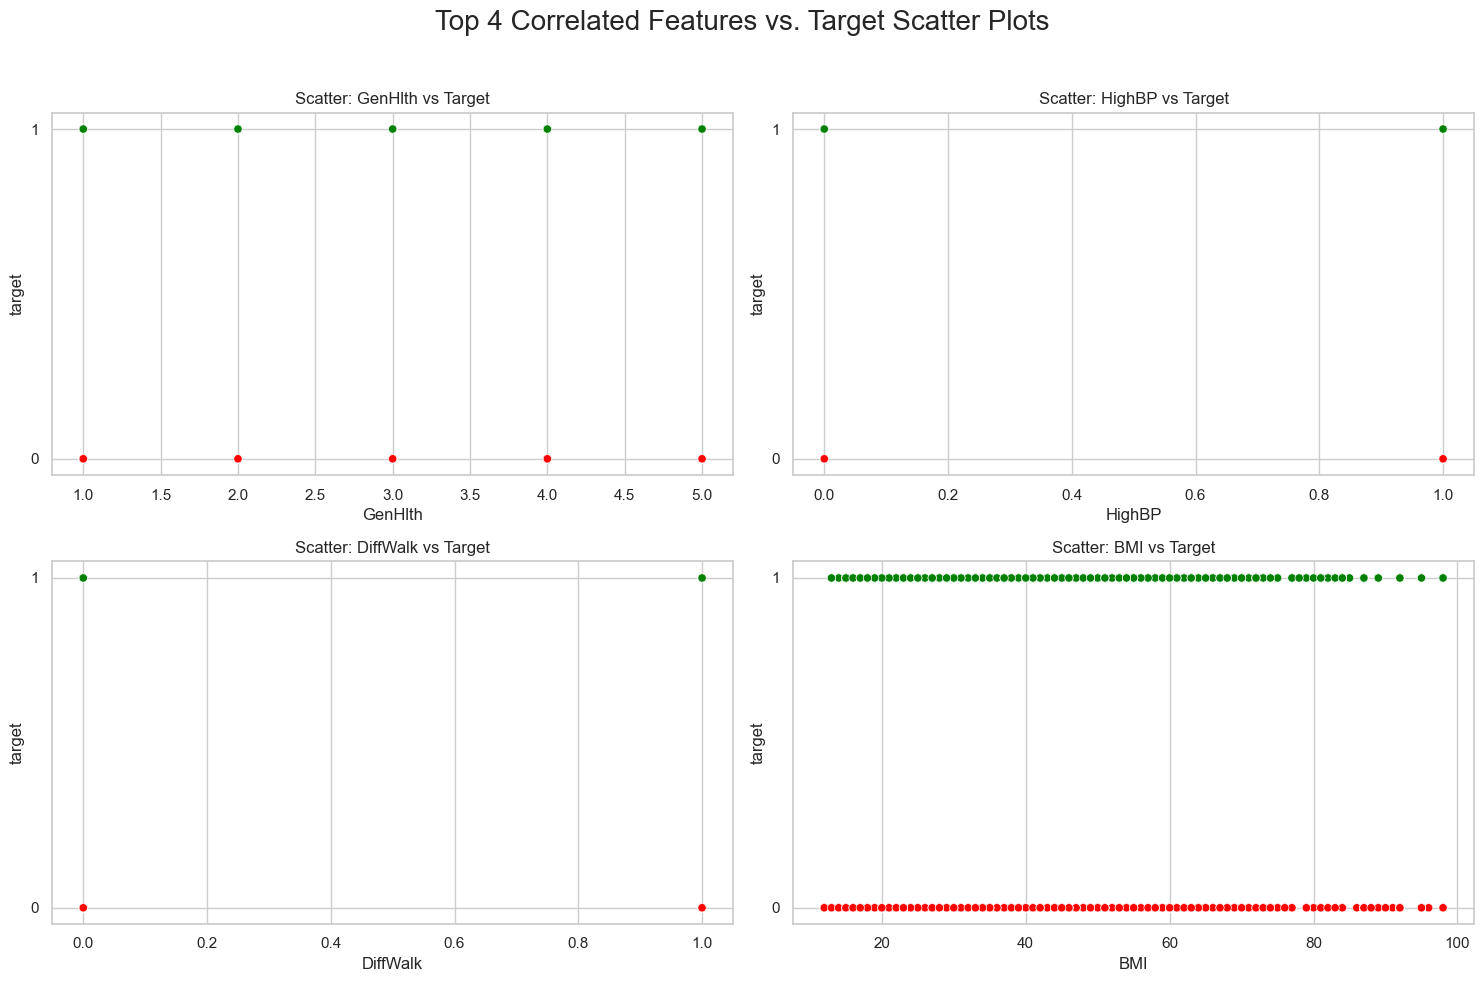

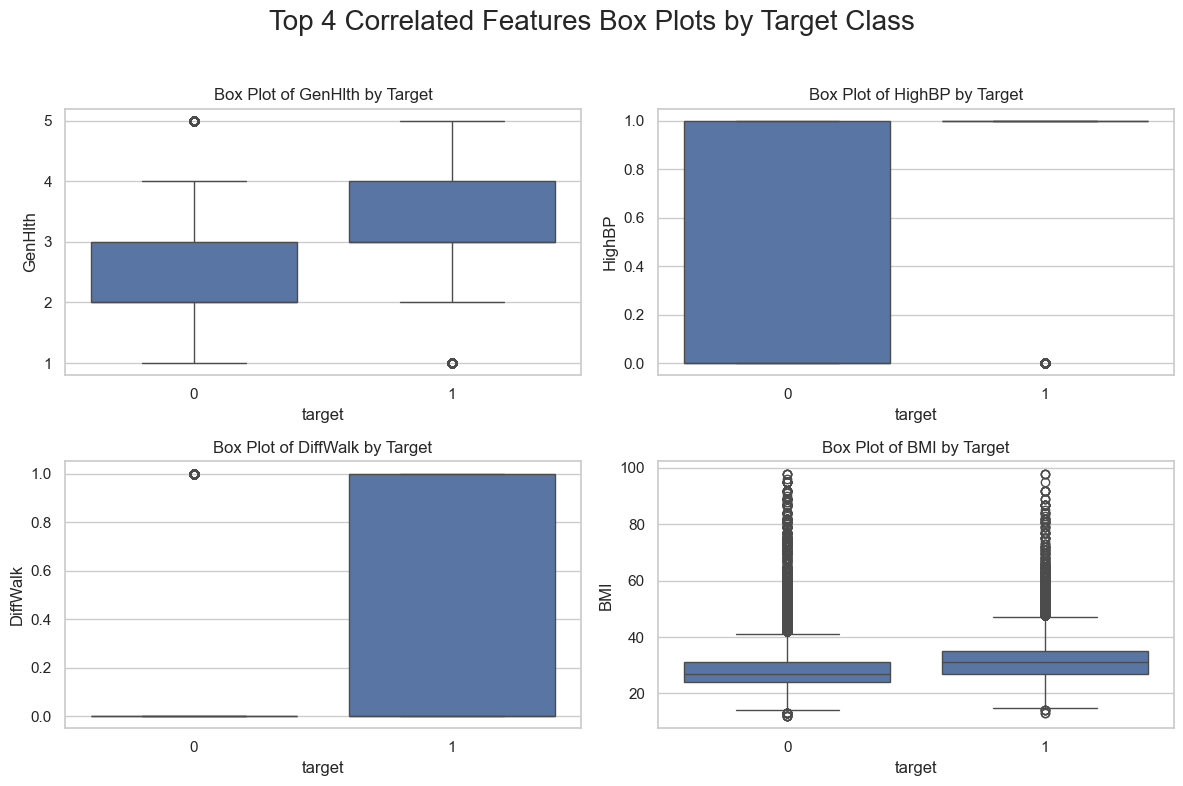

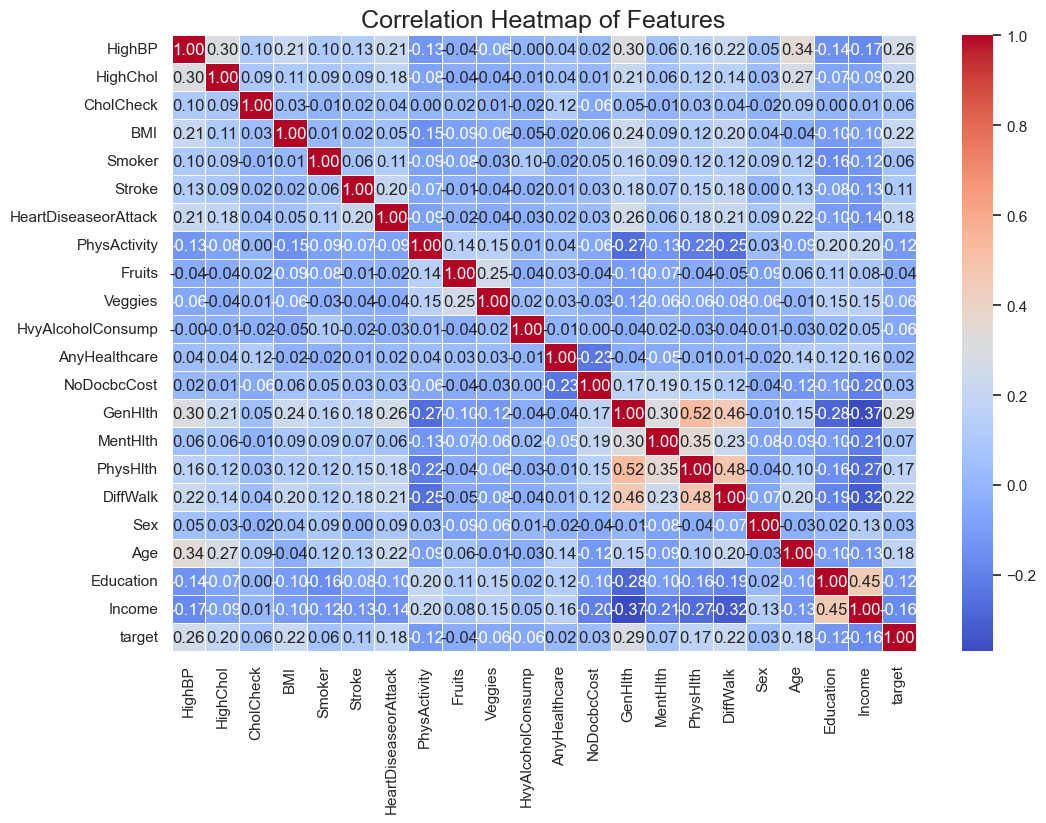

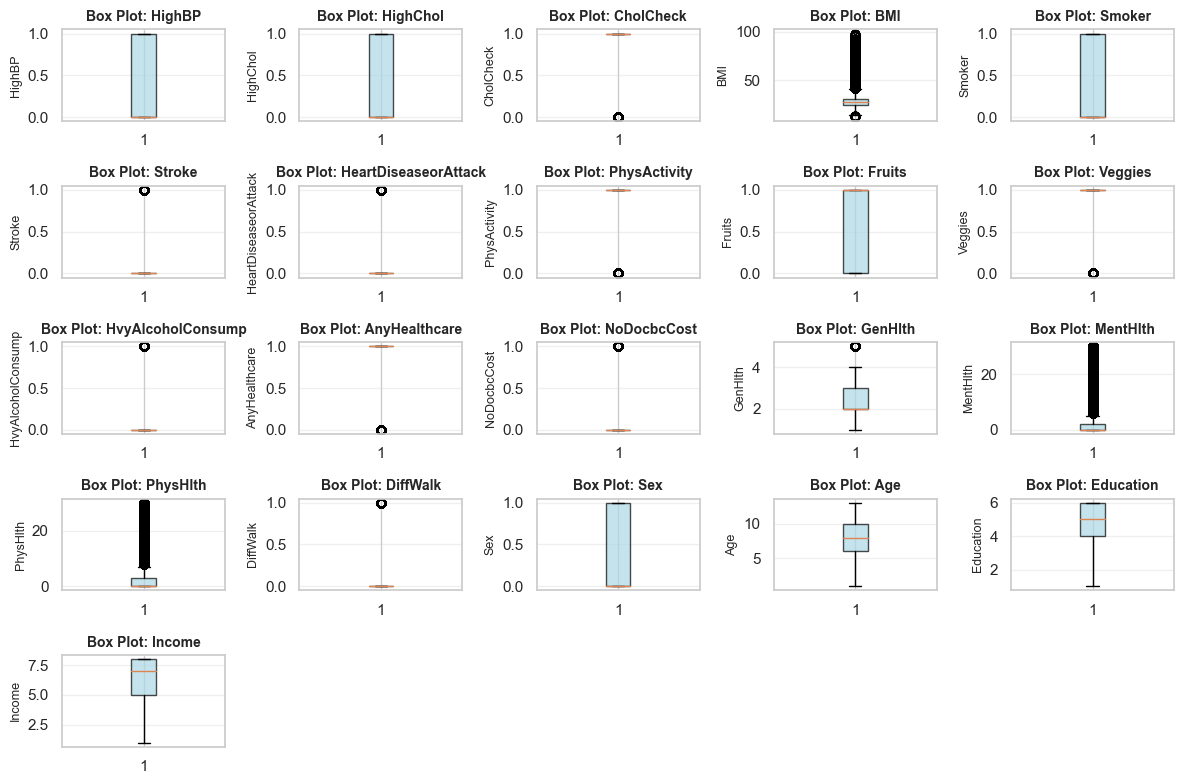

In [18]:
show_visualizations(df)

### Part III

In [82]:
def clean_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure correct data types for each column in the DataFrame.
    - all numbers should be float32
    - categorical variables should be one hot encoded
    - target should always be densely encoded
    """
    ### copy the df to avoid annoying warnings ###
    df_copy = df.copy()

    ### convert numeric columns to float32 ###
    numeric_cols: list[str] = df_copy.select_dtypes(
        include=[np.number]
    ).columns.tolist()
    for col in numeric_cols:
        df_copy[col] = df_copy[col].astype(np.float32)

    ### one-hot encode categorical variables (excluding target) ###
    categorical_cols: list[str] = df_copy.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    categorical_cols = [col for col in categorical_cols if col != TARGET_COLUMN]
    df_copy = pd.get_dummies(df_copy, columns=categorical_cols, drop_first=True)

    ### ensure target is densely encoded ###
    if df_copy[TARGET_COLUMN].dtype == "object" or str(
        df_copy[TARGET_COLUMN].dtype
    ).startswith("category"):
        df_copy[TARGET_COLUMN] = df_copy[TARGET_COLUMN].astype("category").cat.codes

    return df_copy


def impute_data(df: pd.DataFrame) -> pd.DataFrame:
    """"""
    ### copy the df to avoid annoying warnings ###
    df_copy = df.copy()

    ### get all columns with missing values ###
    missing_cols: list[str] = df_copy.columns[df_copy.isnull().any()].tolist()

    ### get the dtypes of those columns ###
    missing_dtypes: dict[str, str] = {
        col: str(df_copy[col].dtype) for col in missing_cols
    }

    ### Impute missing values with column means/modes ###
    for col, dtype in missing_dtypes.items():
        if "float" in dtype or "int" in dtype:
            mean_value = df_copy[col].mean()
            df_copy[col].fillna(mean_value, inplace=True)
        else:
            mode_value = df_copy[col].mode()[0]
            df_copy[col].fillna(mode_value, inplace=True)

    return df_copy


def normalize_data(df: pd.DataFrame) -> pd.DataFrame:
    """"""
    ### copy the df to avoid annoying warnings ###
    df_copy = df.copy()

    ### get all numeric columns ###
    numeric_cols: list[str] = [
        col
        for col in df_copy.select_dtypes(include=[np.number]).columns
        if df_copy[col].nunique() > 4
    ]

    ### normalize each numeric column ###
    for col in numeric_cols:
        col_mean = df_copy[col].mean()
        col_std = df_copy[col].std()
        if col_std != 0:
            df_copy[col] = (df_copy[col] - col_mean) / col_std
        else:
            df_copy[col] = 0.0  # If std is 0, set all values to 0

    return df_copy


def remove_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """"""
    ### copy the df to avoid annoying warnings ###
    df_copy = df.copy()

    ### get all numeric columns ###
    numeric_cols: list[str] = list(set(df_copy.select_dtypes(
        include=[np.number]
    ).columns.tolist()) - set([TARGET_COLUMN]))

    ### remove outliers for each numeric column ###
    for col in numeric_cols:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_copy = df_copy[(df_copy[col] >= lower_bound) & (df_copy[col] <= upper_bound)]

    ### reset index after removing rows ###
    df_copy.reset_index(drop=True, inplace=True)

    return df_copy


def feature_selection(
    df: pd.DataFrame,
    method: FeatureSelectionMethod = FeatureSelectionMethod.MUTUAL_INFORMATION,
) -> pd.DataFrame:
    """
    Args:
        df (pd.DataFrame): Input DataFrame.
    Returns:
        pd.DataFrame: DataFrame with selected features.
    """
    ### copy the df to avoid annoying warnings ###
    df_copy = df.copy()

    ### drop any feature that is constant ###
    nunique = df_copy.nunique()
    constant_features = nunique[nunique <= 1].index.tolist()
    df_copy.drop(columns=constant_features, inplace=True)

    def mutual_information_discrete(x: pd.Series, y: pd.Series) -> float:
        """
        Compute Mutual Information I(X; Y) between two discrete Series.
        """
        ### joint distribution P(x, y)
        joint = pd.crosstab(x, y).astype(float)
        joint /= joint.values.sum()

        ### marginal distributions P(x), P(y)
        p_x = joint.sum(axis=1).values.reshape(-1, 1)
        p_y = joint.sum(axis=0).values.reshape(1, -1)

        ### compute MI with safe division + masking
        denom = p_x * p_y

        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = joint.values / denom
            mask = (joint.values > 0) & np.isfinite(ratio)
            mi = (joint.values[mask] * np.log2(ratio[mask])).sum()

        return float(mi)

    if method == FeatureSelectionMethod.MUTUAL_INFORMATION:
        """
        Feature selection using Mutual Information. This is useful for both
        classification and regression tasks, as it captures any kind of dependency
        between features and the target variable.
        """
        ### compute MI for each feature against the target ###
        mi_scores_raw = {}

        for col in df_copy.columns:
            if col == TARGET_COLUMN:
                continue

            mi_scores_raw[col] = mutual_information_discrete(
                df_copy[col], df_copy[TARGET_COLUMN]
            )

        ### convert to Series for sorting ###
        mi_scores = pd.Series(mi_scores_raw)

        ### sort descending (higher MI = stronger relationship) ###
        mi_scores = mi_scores.sort_values(ascending=False)

        ### keep top 80% features ###
        num_keep = int(0.8 * len(mi_scores))
        threshold = mi_scores.iloc[num_keep - 1]

        selected_features = mi_scores[mi_scores >= threshold].index.tolist()

        ### final filtered DF ###
        df_filtered = df_copy[selected_features + [TARGET_COLUMN]]

        return df_filtered

    if method == FeatureSelectionMethod.CORRELATION:
        """
        Feature selection using Pearson Correlation Coefficient. This method is
        primarily useful for regression tasks where linear relationships are of interest.
        """
        ### compute correlation for each feature against the target ###
        corr_scores = (
            df_copy.drop(columns=[TARGET_COLUMN])  # exclude target from features
            .corrwith(df_copy[TARGET_COLUMN])  # Pearson corr with target
            .abs()  # use absolute correlation
            .fillna(
                0
            )  # fill NaNs with 0 correlation (this is needed as some features may be constant)
            .sort_values(ascending=False)  # sort descending
        )

        ### keep top 80% features ###
        num_keep = int(0.9 * len(corr_scores))
        threshold = corr_scores.iloc[num_keep - 1]

        selected_features = corr_scores[corr_scores > threshold].index.tolist()

        ### final filtered DF ###
        df_filtered = df_copy[selected_features + [TARGET_COLUMN]]

        return df_filtered


def process_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    This is a pipeline that applies a series of data processing functions to the input DataFrame.
    1. Impute missing values
    2. Normalize numeric features
    3. Remove outliers
    4. feature selection (with pearson corr)
    Args:
        df (pd.DataFrame): Input DataFrame to be processed.
    Returns:
        pd.DataFrame: Processed DataFrame.
    """
    ### define the data processing functions ###
    data_processing_functions = [
        clean_dtypes,
        impute_data,
        normalize_data,
        remove_outliers,
        lambda x: feature_selection(x, method=FeatureSelectionMethod.CORRELATION),
    ]

    return reduce(lambda d, f: f(d), data_processing_functions, df)


In [84]:
process_data(df)

,GenHlth,HighBP,BMI,Age,HighChol,Income,Education,Sex,target
0,-0.478618,1.0,-0.511805,0.644315,1.0,0.939636,0.963270,1.0,0.0
1,0.457293,0.0,-0.511805,1.626563,0.0,0.939636,0.963270,1.0,1.0
2,0.457293,1.0,-1.117069,0.644315,1.0,-1.474484,-1.065593,0.0,0.0
3,-1.414529,1.0,-0.209174,1.626563,0.0,-0.991660,-0.051161,0.0,1.0
4,-0.478618,0.0,0.547406,-0.992764,0.0,0.939636,0.963270,0.0,0.0
...,...,...,...,...,...,...,...,...,...
72277,-0.478618,0.0,-0.663121,-2.302427,0.0,-0.026012,-1.065593,1.0,0.0
72278,1.393205,1.0,0.850037,0.316900,1.0,-1.474484,-1.065593,1.0,0.0
72279,0.457293,1.0,0.093458,-0.010516,0.0,-1.957309,-0.051161,0.0,0.0
72280,-0.478618,0.0,-0.057858,-1.975011,0.0,-0.991660,0.963270,0.0,0.0


### Part IV

In [90]:
def show_statistical_characterization(df: pd.DataFrame) -> pd.DataFrame:
    """
    3. Statistical Characterization (Req. 2.4)
        - Computes extended descriptive statistics for all numerical features
          (count, mean, median, std, variance, min, max, range).
        - Prints the resulting statistics table.
    """
    ### Select numeric features (exclude target) ###
    numeric_features = df.drop(columns="target")

    ### Compute descriptive statistics ###
    stats_summary = numeric_features.describe().T

    ### Add median ###
    stats_summary["median"] = numeric_features.median()

    ### Add variance ###
    stats_summary["variance"] = numeric_features.var()

    ### Add range (max - min) ###
    stats_summary["range"] = numeric_features.max() - numeric_features.min()

    ### Reorder columns for clarity ###
    stats_summary = stats_summary[
        ["count", "mean", "median", "std", "variance", "min", "max", "range"]
    ]

    return stats_summary


In [92]:
stats_summary = show_statistical_characterization(df)
print("\nStatistical Characterization of Numerical Data:")
stats_summary


Statistical Characterization of Numerical Data:


,count,mean,median,std,variance,min,max,range
HighBP,253680.0,0.429001,0.0,0.494934,0.244960,0.0,1.0,1
HighChol,253680.0,0.424121,0.0,0.494210,0.244243,0.0,1.0,1
CholCheck,253680.0,0.962670,1.0,0.189571,0.035937,0.0,1.0,1
BMI,253680.0,28.382364,27.0,6.608694,43.674839,12.0,98.0,86
Smoker,253680.0,0.443169,0.0,0.496761,0.246771,0.0,1.0,1
Stroke,253680.0,0.040571,0.0,0.197294,0.038925,0.0,1.0,1
HeartDiseaseorAttack,253680.0,0.094186,0.0,0.292087,0.085315,0.0,1.0,1
PhysActivity,253680.0,0.756544,1.0,0.429169,0.184186,0.0,1.0,1
Fruits,253680.0,0.634256,1.0,0.481639,0.231976,0.0,1.0,1
Veggies,253680.0,0.811420,1.0,0.391175,0.153018,0.0,1.0,1


## ============================================================================
## SECTION III
## ============================================================================

### Part I

In [93]:
def split(df: pd.DataFrame, ratios: dict[str, float]) -> dict[str, tensor_t]:
    """"""
    ### insure the ratios sum to 1.0 ###
    total_ratio: float = sum(ratios.values())
    if not abs(total_ratio - 1.0) < 1e-6:
        raise ValueError("Ratios must sum to 1.0")

    ### shuffle the dataframe ###
    df = df.sample(frac=1, random_state=RNG).reset_index(drop=True)

    ### compute the split indices ###
    split_indices: list = []
    cumulative_ratio: float = 0.0
    split_index: int
    for ratio in ratios.values():
        cumulative_ratio += ratio
        split_index = int(cumulative_ratio * len(df))
        split_indices.append(split_index)

    ### split the dataframe ###
    splits: dict = {}
    previous_index: int = 0
    for i, (split_name, _) in enumerate(ratios.items()):
        split_index = split_indices[i]
        split_df: pd.DataFrame = df.iloc[previous_index:split_index]

        ### separate features and target ###
        X: tensor_t = split_df.drop(columns=[TARGET_COLUMN]).to_numpy()
        y: tensor_t = split_df[TARGET_COLUMN].to_numpy().reshape(-1, 1)

        ### store the split ###
        splits[split_name] = (X, y)

        ### update previous index ###
        previous_index = split_index

    ### assure all data is used ###
    assert previous_index == len(df), "Not all data was used in the splits."

    return splits


In [95]:
splits = split(df, RATIOS)
tr_X, tr_y = splits["train"]
vl_X, vl_y = splits["validation"]
ts_X, ts_y = splits["test"]

### Part II

In [97]:
def batch_data(X: tensor_t, y: tensor_t, batch_size: int) -> tuple[tensor_t, tensor_t]:
    """
    Generate mini-batches from the dataset.
    Args:
        X (tensor_t): Feature matrix.
        y (tensor_t): Target vector.
        batch_size (int): Size of each mini-batch.
    Returns:
        tuple[nd.ndarray, ndarray]: a tuple containing mini-batches of features and targets.
    """
    ### init some stuff ###
    n_samples = X.shape[0]
    n_full_batches = n_samples // batch_size

    ### quick error check ###
    if n_full_batches == 0:
        raise ValueError("batch_size is larger than the number of samples.")

    ### trim off the remainder so all batches are equal ###
    x_trimmed = X[: n_full_batches * batch_size]
    y_trimmed = y[: n_full_batches * batch_size]

    ### split into equal-sized batches (no remainder) ###
    x_batches = np.array(np.split(x_trimmed, n_full_batches))
    y_batches = np.array(np.split(y_trimmed, n_full_batches))

    return (x_batches, y_batches)


### Part III

In [98]:
####################################
### ~~~ ACTIVATION FUNCTIONS ~~~ ###
####################################


def relu(x: tensor_t) -> tensor_t:
    """
    Apply the ReLU activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Output tensor after applying ReLU.
    """
    return np.maximum(0, x)


def relu_derivative(x: tensor_t) -> tensor_t:
    """
    Compute the derivative of the ReLU activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Derivative of ReLU.
    """

    return (x > 0).astype(x.dtype)


def sigmoid(x: tensor_t) -> tensor_t:
    """
    Apply the Sigmoid activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Output tensor after applying Sigmoid.
    """

    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x: tensor_t) -> tensor_t:
    """
    Compute the derivative of the Sigmoid activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Derivative of Sigmoid.
    """

    sig = sigmoid(x)
    return sig * (1 - sig)


def tanh(x: tensor_t) -> tensor_t:
    """
    Apply the Tanh activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Output tensor after applying Tanh.
    """

    return np.tanh(x)


def tanh_derivative(x: tensor_t) -> tensor_t:
    """
    Compute the derivative of the Tanh activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Derivative of Tanh.
    """

    return 1 - np.tanh(x) ** 2


def linear(x: tensor_t) -> tensor_t:
    """
    Apply the Linear activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Output tensor after applying Linear.
    """

    return x


def linear_derivative(x: tensor_t) -> tensor_t:
    """
    Compute the derivative of the Linear activation function.
    Args:
        x (tensor_t): Input tensor.
    Returns:
        tensor_t: Derivative of Linear.
    """

    return np.ones_like(x)


ACTIVATION_FUNCTIONS: dict[ActivationFunction, Callable[[tensor_t], tensor_t]] = {
    ActivationFunction.RELU: relu,
    ActivationFunction.SIGMOID: sigmoid,
    ActivationFunction.TANH: tanh,
    ActivationFunction.LINEAR: linear,
}
ACTIVATION_DERIVATIVES: dict[ActivationFunction, Callable[[tensor_t], tensor_t]] = {
    ActivationFunction.RELU: relu_derivative,
    ActivationFunction.SIGMOID: sigmoid_derivative,
    ActivationFunction.TANH: tanh_derivative,
    ActivationFunction.LINEAR: linear_derivative,
}


##############################
### ~~~ LOSS FUNCTIONS ~~~ ###
##############################


def binary_cross_entropy(y_true: tensor_t, y_pred: tensor_t) -> float:
    """
    Compute the Binary Cross-Entropy loss.
    Args:
        y_true (tensor_t): True labels.
        y_pred (tensor_t): Predicted labels.
    Returns:
        float: Binary Cross-Entropy loss.
    """
    ### avoid log(0) ###
    epsilon: float = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    ### compute BCE ###
    bce: float = (
        -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    ).astype(float)

    return bce


def mean_squared_error(y_true: tensor_t, y_pred: tensor_t) -> float:
    """
    Compute the Mean Squared Error loss.
    Args:
        y_true (tensor_t): True labels.
        y_pred (tensor_t): Predicted labels.
    Returns:
        float: Mean Squared Error loss.
    """
    mse: float = np.mean((y_true - y_pred) ** 2).astype(float)
    return mse


def binary_cross_entropy_derivative(y_true: tensor_t, y_pred: tensor_t) -> tensor_t:
    """
    Compute the derivative of the Binary Cross-Entropy loss.
    Args:
        y_true (tensor_t): True labels.
        y_pred (tensor_t): Predicted labels.
    Returns:
        tensor_t: Derivative of Binary Cross-Entropy loss.
    """
    raise DeprecationWarning(
        "Use bce_with_sigmoid_last_layer_grad instead for numerical stability."
    )
    ### avoid division by zero ###
    epsilon: float = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    ### compute derivative ###
    bce_derivative: tensor_t = (
        -((y_true / y_pred) - ((1 - y_true) / (1 - y_pred))) / y_true.shape[0]
    )

    return bce_derivative


def bce_with_sigmoid_last_layer_grad(y_true: tensor_t, y_pred: tensor_t) -> tensor_t:
    """
    Gradient of binary cross-entropy wrt the *pre-activation* z
    of the last sigmoid layer.

    For sigmoid + BCE, we have:
        dL/dz = (y_pred - y_true) / m
    """
    m = y_true.shape[0]
    return (y_pred - y_true) / m


def mean_squared_error_derivative(y_true: tensor_t, y_pred: tensor_t) -> tensor_t:
    """
    Compute the derivative of the Mean Squared Error loss.
    Args:
        y_true (tensor_t): True labels.
        y_pred (tensor_t): Predicted labels.
    Returns:
        tensor_t: Derivative of Mean Squared Error loss.
    """
    mse_derivative: tensor_t = (2 * (y_pred - y_true)) / y_true.shape[0]
    return mse_derivative


LOSS_FUNCTIONS: dict[LossFunction, Callable[[tensor_t, tensor_t], float]] = {
    LossFunction.BCE: binary_cross_entropy,
    LossFunction.MSE: mean_squared_error,
}

LOSS_DERIVATIVES: dict[LossFunction, Callable[[tensor_t, tensor_t], tensor_t]] = {
    LossFunction.BCE: bce_with_sigmoid_last_layer_grad,
    LossFunction.MSE: mean_squared_error_derivative,
}


################################
### ~~~ ACCURACY METRICS ~~~ ###
################################


def binary_accuracy(y_true: tensor_t, y_pred: tensor_t) -> float:
    """
    Compute the accuracy for binary classification.
    Args:
        y_true (tensor_t): True labels.
        y_pred (tensor_t): Predicted labels.
    Returns:
        float: Accuracy score.
    """
    y_pred_labels = (y_pred >= 0.5).astype(int)
    accuracy = np.mean(y_true == y_pred_labels).astype(float)
    return accuracy


ACCURACY_METRICS: dict[AccuracyMetric, Callable[[tensor_t, tensor_t], float]] = {
    AccuracyMetric.BINARY_ACCURACY: binary_accuracy,
}

### Part IV

#### Layer Definition

In [99]:
def create_layer(
    input_dim: dim_t,
    output_dim: dim_t,
    activation: ActivationFunction,
    name: str = "layer",
) -> Layer:
    """
    Create a neural network layer with initialized weights and bias.
    the weights are initialized using He initialization
    Args:
        name (str): The name of the layer.
        input_dim (dim_t): The input dimensions of the layer.
        output_dim (dim_t): The output dimensions of the layer.
        activation (ActivationFunction): The activation function for the layer.
    Returns:
        Layer: The created neural network layer.
    """
    ### initialize weights and bias ###
    weights: tensor_t = RNG.standard_normal((input_dim[0], output_dim[0])) * np.sqrt(
        2.0 / input_dim[0]
    )
    bias: tensor_t = np.zeros((1, output_dim[0]))

    ### create the layer ###
    layer: Layer = Layer(
        name=name,
        input_dim=input_dim,
        output_dim=output_dim,
        activation=activation,
        weights=weights,
        bias=bias,
        x=None,
        z=None,
    )

    return layer


def call_layer(layer: Layer, x: tensor_t) -> tensor_t:
    """
    Perform a forward pass through the layer.
    Args:
        layer (Layer): The neural network layer.
        x (tensor_t): The input tensor to the layer.
    Returns:
        tensor_t: The output tensor after applying the layer's weights, bias, and activation function.
    """
    ### compute the linear combination ###
    z: tensor_t = np.dot(x, layer.weights) + layer.bias

    ### apply the activation function ###
    a: tensor_t = ACTIVATION_FUNCTIONS[layer.activation](z)

    ### store intermediate values ###
    layer.x = x
    layer.z = z

    return a


def layer_to_str(layer: Layer) -> str:
    """
    Generate a string representation of the layer.
    Args:
        layer (Layer): The neural network layer.
    Returns:
        str: String representation of the layer.
    """
    return (
        f"Layer(name={layer.name}, input_dim={layer.input_dim}, "
        f"output_dim={layer.output_dim}, activation={layer.activation})"
    )

#### Model Definition

In [101]:
def create_model(
    layers: list[Layer],
    loss_function: LossFunction,
    accuracy_function: AccuracyMetric = AccuracyMetric.BINARY_ACCURACY,
    learning_rate: float = 0.001,
) -> Model:
    """
    Create a neural network model.
    Args:
        layers (list[Layer]): The layers of the model.
        loss_function (LossFunction): The loss function for the model.
        learning_rate (float): The learning rate for training.
    Returns:
        Model: The created neural network model.
    """
    ### insure that the dimensions match ###
    for i in range(1, len(layers)):
        if layers[i - 1].output_dim != layers[i].input_dim:
            raise ValueError(
                f"Layer {i} input dimension {layers[i].input_dim} does not match "
                f"previous layer output dimension {layers[i - 1].output_dim}"
            )

    ### create the model ###
    model: Model = Model(
        layers=layers,
        loss_function=loss_function,
        learning_rate=learning_rate,
        accuracy_function=accuracy_function,
    )

    return model


def call_model(model: Model, x: tensor_t) -> tensor_t:
    """
    Forward pass through the model.
    Args:
        model (Model): The neural network model.
        x (tensor_t): The input tensor.
    Returns:
        tensor_t: The output tensor after passing through the model.
    """
    ### make sure x has the right shape ###
    if x.shape[1] != model.layers[0].input_dim[0]:
        raise ValueError(
            f"Input tensor shape {x.shape} does not match model input dimension "
            f"{model.layers[0].input_dim}"
        )

    ### pass through each layer ###
    for layer in model.layers:
        x = call_layer(layer, x)

    return x


def compute_loss(model: Model, y_true: tensor_t, y_pred: tensor_t) -> float:
    """
    Compute the loss of the model.
    Args:
        model (Model): The neural network model.
        y_true (tensor_t): The true labels.
        y_pred (tensor_t): The predicted labels.
    Returns:
        float: The computed loss.
    """
    loss_function = LOSS_FUNCTIONS[model.loss_function]
    loss: float = loss_function(y_true, y_pred)

    return loss


def comptute_accuracy(model: Model, y_true: tensor_t, y_pred: tensor_t) -> float:
    """
    Compute the accuracy of the model.
    Args:
        model (Model): The neural network model.
        y_true (tensor_t): The true labels.
        y_pred (tensor_t): The predicted labels.
    Returns:
        float: The computed accuracy.
    """
    accuracy_function = ACCURACY_METRICS[model.accuracy_function]
    accuracy: float = accuracy_function(y_true, y_pred)

    return accuracy


def compute_gradients(
    model: Model, x_batch: tensor_t, y_batch: tensor_t
) -> list[Gradients]:
    """"""
    ### forward pass to fill the cache ###
    y_pred: tensor_t = call_model(model, x_batch)

    ### compute loss derivative ###
    dL_dy: tensor_t = LOSS_DERIVATIVES[model.loss_function](y_batch, y_pred)

    ### prepare for the backward pass ###
    grads_list: list[Gradients] = []
    grad_next: tensor_t = dL_dy
    rev_layers: list[Layer] = model.layers[::-1]

    ### backward pass ###
    for idx, layer in enumerate(rev_layers):
        """
        Backward pass through a single layer.
        """
        ## get the cached values ##
        x: tensor_t | None = layer.x
        z: tensor_t | None = layer.z

        ## sanity check ##
        if x is None or z is None:
            raise ValueError(
                f"Layer {layer.name} cache is empty. Forward pass must be called "
                "before backward pass."
            )

        ## decide how to get dL/dz ##
        if (
            idx == 0
            and model.loss_function is LossFunction.BCE
            and layer.activation is ActivationFunction.SIGMOID
        ):
            """
            This is done for numerical stability, as the derivative of BCE and sigmoid
            result in a singularity when combined.
            This in essence drops the derivative of the activation function from the equation.
            As we are accounting for it in the derivative of the loss function directly.
            the derivative of the loss can be found in util.py -> bce_with_sigmoid_last_layer_grad
            """
            dL_dz: tensor_t = grad_next
        else:
            # get the derivative of the activation function #
            """
            dL_dz = dL_dy * activation_derivative(z)
            dL_dy is the gradient from the next layer
            """
            activation_derivative = ACTIVATION_DERIVATIVES[layer.activation]
            dL_dz: tensor_t = activation_derivative(z) * grad_next

        ## compute the derivative w.r.t. weights ##
        """
        dL_dw = x.T dot dL_dz / m (where m is the number of samples) 
            dimensions: (input_dim, m) dot (m, output_dim) = (input_dim, output_dim) [same as weights]
        """
        dL_dw: tensor_t = np.dot(x.T, dL_dz) / x.shape[0]

        ## compute the derivative w.r.t. bias ##
        """
        dL_db = sum(dL_dz, axis=0, keepdims=True) / m
            dimensions: (1, output_dim) [same as bias]
        """
        dL_db: tensor_t = np.sum(dL_dz, axis=0, keepdims=True) / x.shape[0]

        ## compute the derivative w.r.t. input ##
        """
        dL_dx = dL_dz dot weights.T
            dimensions: (m, output_dim) dot (output_dim, input_dim) = (m, input_dim) [same as x]
        """
        dL_dx: tensor_t = np.dot(dL_dz, layer.weights.T)

        ## store the gradients ##
        grads: Gradients = Gradients(dW=dL_dw, db=dL_db)
        grads_list.append(grads)

        ## update grad_next for the next layer ##
        grad_next = dL_dx

    ### reverse the gradients list to match the layer order ###
    grads_list.reverse()

    return grads_list


def model_to_str(model: Model) -> str:
    """
    Generate a string representation of the model.
    Args:
        model (Model): The neural network model.
    Returns:
        str: String representation of the model.
    """
    layer_strs: list[str] = [layer_to_str(layer) for layer in model.layers]
    model_str: str = (
        "Model(layers=[\n  " + ",\n  ".join(layer_strs) + f"\n], "
        f"loss_function={model.loss_function}, "
        f"learning_rate={model.learning_rate})"
    )

    return model_str


def train_model(
    model: Model,
    train_data: tuple[tensor_t, tensor_t],
    val_data: tuple[tensor_t, tensor_t],
    epochs: int,
    batch_size: int,
    optimiser: optimiser_t,
    callbacks: list[callback_t] = [],
    do_shuffle: bool = True,
    verbose: bool = True,
) -> History:
    """
    This function trains the model using whatever optimiser is passed to it.
    It does the following:
    - Initialises the history object to track training and validation loss and accuracy.
    - Shuffles the training data if specified.
    - Batches the training data.
    - For each epoch:
        - For each batch:
            - Performs a forward pass.
            - Computes the loss and accuracy.
            - Computes the gradients.
            - Applies the gradients using the optimiser.
            - Updates the history.
        - Computes validation loss and accuracy.
        - Calls any callbacks with the current state.
        - Checks for early stopping.
    Args:
        model (Model): The neural network model to be trained.
        train_data (tuple[tensor_t, tensor_t]): The training data (features and labels).
        val_data (tuple[tensor_t, tensor_t]): The validation data (features and labels).
        epochs (int): The number of epochs to train the model.
        batch_size (int): The size of each training batch.
        optimiser (optimiser_t): The optimiser function to apply gradients.
        callbacks (list[callback_t], optional): List of callback functions to be called
            at the end of each epoch. Defaults to [].
        do_shuffle (bool, optional): Whether to shuffle the training data before each epoch.
            Defaults to True.
    Returns:
        History: The training history containing loss and accuracy for training and validation.
    """
    ### init history ###
    history: History = History(
        train_loss=[],
        val_loss=[],
        train_accuracy=[],
        val_accuracy=[],
    )

    ### unpack data ###
    tr_X, tr_y = train_data
    val_X, val_y = val_data

    ### shuffle training data ###
    if do_shuffle:
        perm: np.ndarray = RNG.permutation(tr_X.shape[0])
        tr_X = tr_X[perm]
        tr_y = tr_y[perm]

    ### batch training data ###
    tr_X_batches, tr_y_batches = batch_data(tr_X, tr_y, batch_size)

    ### training loop ###
    for _ in trange(epochs, desc="Training Epochs", disable=not verbose):
        current_loss = 0.0
        current_accuracy = 0.0
        for X_batch, y_batch in zip(tr_X_batches, tr_y_batches):
            """
            1. do a forward pass
            2. compute the loss
            3. compute the accuracy
            4. compute the gradients
            5. apply the gradients
            6. track the history
            """
            ### call the model ###
            y_pred = call_model(model, X_batch)

            ### compute loss ###
            loss = compute_loss(model, y_batch, y_pred)

            ### compute accuracy ###
            accuracy = comptute_accuracy(model, y_batch, y_pred)

            ### compute gradients ###
            grads = compute_gradients(model, X_batch, y_batch)

            ### apply gradients ###
            optimiser(model, grads)

            ### track history ###
            current_loss += loss
            current_accuracy += accuracy

        ### average history over all batches ###
        average_loss = current_loss / len(tr_X)
        history.train_loss.append(average_loss)
        average_accuracy = current_accuracy / len(tr_X)
        history.train_accuracy.append(average_accuracy)

        ### validation loss ###
        y_val_pred = call_model(model, val_X)
        val_loss = compute_loss(model, val_y, y_val_pred)
        history.val_loss.append(val_loss)
        val_accuracy = comptute_accuracy(model, val_y, y_val_pred)
        history.val_accuracy.append(val_accuracy)

        ### Construct state for callbacks ###
        state = State(
            epoch=epochs,
            model=model,
            history=history,
            train_loss=average_loss,
            val_loss=val_loss,
        )

        ### call callbacks ###
        for cb in callbacks:
            cb(state)

        ### check for early stopping ###
        if state.stop_training:
            break

    return history


#### Callbacks Definitions

In [102]:
def make_early_stopping_callback(
    patience: int = 5,
    min_delta: float = 0.0,
) -> callback_t:
    """
    Create an early stopping callback based on validation loss.
    Args:
        patience (int): Number of epochs to wait for improvement before stopping.
        min_delta (float): Minimum change in validation loss to qualify as improvement.
    Returns:
        Callback: A callback function for early stopping. (THIS IS CLOSURE)
    """

    best_val_loss: float = float("inf")
    epochs_without_improve: int = 0

    def callback(state: State) -> None:
        nonlocal best_val_loss, epochs_without_improve

        current_val_loss = state.val_loss

        ### check improvement ###
        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        ### trigger stop if patience exhausted ###
        if epochs_without_improve >= patience:
            state.stop_training = True

    return callback


def make_lr_annealing_callback(
    factor: float = 0.5,
    patience: int = 5,
    min_delta: float = 0.0,
    min_lr: float = 1e-5,
) -> callback_t:
    """
    Reduce learning rate by `factor` if validation loss does not improve
    for `patience` epochs.
    Args:
        factor (float): Factor to reduce learning rate by.
        patience (int): Number of epochs to wait for improvement before reducing LR.
        min_delta (float): Minimum change in validation loss to qualify as improvement.
        min_lr (float): Minimum learning rate allowed.
    Returns:
        Callback: A callback function for learning rate annealing. (THIS IS CLOSURE)
    """

    best_val_loss: float = float("inf")
    epochs_without_improve: int = 0

    def callback(state: State) -> None:
        nonlocal best_val_loss, epochs_without_improve

        model: Model = state.model
        current_val_loss = state.val_loss

        ### check improvement ###
        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            epochs_without_improve = 0
            return

        epochs_without_improve += 1

        ### update LR if plateau ###
        if epochs_without_improve >= patience:
            old_lr = model.learning_rate
            new_lr = max(old_lr * factor, min_lr)

            if new_lr < old_lr:
                model.learning_rate = new_lr

            epochs_without_improve = 0  # reset patience after LR change

    return callback

#### Optimiser Definitions

In [103]:
def make_minibatch_sgd_optimiser(
    batch_size: int,
) -> optimiser_t:
    """
    Create a mini-batch SGD optimiser.
    Args:
        batch_size (int): The size of each mini-batch. (Not used in this function as the gradients are assumed to be pre-computed for the mini-batch)
    Returns:
        Optimiser: A mini-batch SGD optimiser function. (THIS IS CLOSURE)
    """

    def step(model: Model, gradients_list: list[Gradients]) -> None:
        """
        Perform a single optimization step using mini-batch SGD.
        Args:
            model (Model): The neural network model.
            gradients_list (list[Gradients]): List of gradients for each layer.
        Returns:
            None
        """
        for layer, gradients in zip(model.layers, gradients_list):
            layer.weights -= model.learning_rate * gradients.dW
            layer.bias -= model.learning_rate * gradients.db

    return step


def make_adam_optimizer(
    model: Model,
    learning_rate: float | None = None,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps: float = 1e-8,
) -> optimiser_t:
    """
    Adam optimizer.

    learning_rate:
        If None, uses model.learning_rate.
    """
    ### init the Adam state by using Closure ###
    lr = learning_rate
    t: int = 0

    ### initialize first and second moment vectors ###
    m_w: list[tensor_t] = []
    v_w: list[tensor_t] = []
    m_b: list[tensor_t] = []
    v_b: list[tensor_t] = []

    ### for each layer, initialize m and v ###
    for layer in model.layers:
        m_w.append(np.zeros_like(layer.weights))
        v_w.append(np.zeros_like(layer.weights))
        m_b.append(np.zeros_like(layer.bias))
        v_b.append(np.zeros_like(layer.bias))

    def step(model_inner: Any, grads_list: list[Gradients]) -> None:
        """"""
        ### use nonlocal to modify t from the outer scope ###
        nonlocal t
        t += 1

        ### determine learning rate ###
        base_lr = lr if lr is not None else model_inner.learning_rate

        for i, (layer, grads) in enumerate(zip(model_inner.layers, grads_list)):
            """"""
            ## unpack gradients ##
            gW = grads.dW
            gB = grads.db

            ## update biased first moment estimate ##
            """
            m_t = beta_1 * m_{t-1} + (1 - beta_1) * g_t
            """
            m_w[i] = beta1 * m_w[i] + (1 - beta1) * gW
            m_b[i] = beta1 * m_b[i] + (1 - beta1) * gB

            ## update biased second moment estimate ##
            """
            v_t = beta_2 * v_{t-1} + (1 - beta_2) * (g_t * g_t)
            """
            v_w[i] = beta2 * v_w[i] + (1 - beta2) * (gW * gW)
            v_b[i] = beta2 * v_b[i] + (1 - beta2) * (gB * gB)

            ## compute bias-corrected first moment estimate ##
            """
            This is necessary because m and v are initialized as zero vectors,
            m_hat = m_i / (1 - beta_1**t)
            v_hat = v_i / (1 - beta_2**t)
            """
            m_w_hat = m_w[i] / (1 - beta1**t)
            m_b_hat = m_b[i] / (1 - beta1**t)
            v_w_hat = v_w[i] / (1 - beta2**t)
            v_b_hat = v_b[i] / (1 - beta2**t)

            ## update parameters ##
            layer.weights -= base_lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
            layer.bias -= base_lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

    return step


def _newton_schulz_orthogonalize(
    M: tensor_t,
    num_iters: int = 5,
    eps: float = 1e-8,
) -> tensor_t:
    """
    Approximate the closest orthogonal matrix to M using Newton–Schulz iteration.
    Steps:
        1. Frobenius-normalize M:
               X_0 = M / ||M||_F
        2. Iterate:
               X_{k+1} = 0.5 * X_k * (3I - X_k^T X_k)
    Note:
        - This expects a 2D matrix (shape: [rows, cols]).
        - For non-2D tensors, caller should handle reshaping or skipping.
    Args:
        M (tensor_t): Input matrix to be orthogonalized.
        num_iters (int): Number of Newton–Schulz iterations to perform.
        eps (float): Small constant to avoid division by zero.
    Returns:
        tensor_t: Approximate orthogonal matrix.
    """

    ### make sure it's 2D ###
    if M.ndim != 2:
        # caller MUST decide how to handle higher dims
        # here we simply return M unchanged
        return M

    ## compute Frobenius norm ##
    """
    ||M||_F = sqrt(sum(M_ij^2))
    We add eps to avoid division by zero when M is all zeros.
    """
    frob_norm: float = (np.linalg.norm(M, ord="fro") + eps).astype(float)

    ## initialize X_0 ##
    X: tensor_t = M / frob_norm

    ## Newton–Schulz iterations ##
    for _ in range(num_iters):
        """
        X_{k+1} = 0.5 * X_k * (3I - X_k^T X_k)
        """
        XtX: tensor_t = X.T @ X  # shape: (cols, cols)
        eye: tensor_t = np.eye(XtX.shape[0], dtype=X.dtype)
        X = 0.5 * X @ (3.0 * eye - XtX)

    return X


def make_muon_optimizer(
    model: Model,
    learning_rate: float | None = None,
    momentum: float = 0.95,
    num_ns_iters: int = 5,
    eps: float = 1e-8,
) -> optimiser_t:
    """
    Muon optimizer.

    High-level idea:
        1. Maintain a momentum buffer M_t for each weight matrix:
               M_t = momentum * M_{t-1} + g_t
        2. Orthogonalize M_t via Newton–Schulz iteration:
               O_t = orthogonalize(M_t)
        3. Update parameters with orthogonalized step:
               W <- W - lr * sigma * O_t
           where sigma is a scaling factor based on the matrix shape.

    Notes:
        - Muon is defined for 2D matrices (e.g., linear layer weights with shape [in_dim, out_dim]).
        - Biases (1D vectors) are typically updated with standard momentum SGD and not orthogonalized.
        - For conv kernels etc., one would reshape to 2D, apply NS, then reshape back.
          Here we assume simple 2D dense layers.

    Args:
        model (Model):
            The model whose parameters we will optimize.
        learning_rate (float | None):
            If None → use model.learning_rate on each step.
        momentum (float):
            Momentum factor for the running gradient buffer (e.g., 0.95).
        num_ns_iters (int):
            Number of Newton–Schulz refinement iterations.
        eps (float):
            Small constant for numerical stability (norms, etc.).

    Returns:
        optimiser_t:
            A closure `step(model, grads_list)` that performs one Muon update.
    """

    ### init the Muon state by using Closure ###
    lr = learning_rate

    ### momentum buffers for weights and biases ###
    M_w: list[tensor_t] = []
    M_b: list[tensor_t] = []

    ### for each layer, initialize momentum buffers ###
    for layer in model.layers:
        M_w.append(np.zeros_like(layer.weights))
        M_b.append(np.zeros_like(layer.bias))

    def step(model_inner: Any, grads_list: list[Gradients]) -> None:
        """"""
        ### determine learning rate ###
        base_lr = lr if lr is not None else model_inner.learning_rate

        for i, (layer, grads) in enumerate(zip(model_inner.layers, grads_list)):
            """"""
            ## unpack gradients ##
            gW: tensor_t = grads.dW
            gB: tensor_t = grads.db

            ## update momentum buffer for weights ##
            """
            M_t = momentum * M_{t-1} + g_t
            """
            M_w[i] = momentum * M_w[i] + gW

            ## update momentum buffer for biases (no orthogonalization) ##
            """
            For biases (1D), Muon typically does not apply the orthogonalization step.
            We just use classic momentum SGD for them.
            """
            M_b[i] = momentum * M_b[i] + gB

            ## orthogonalize momentum for weights using Newton–Schulz ##
            """
            Only valid for 2D matrices.
            If the weight tensor is not 2D, we skip orthogonalization and fall back to
            using the raw momentum buffer.
            """
            if layer.weights.ndim == 2:
                O_w: tensor_t = _newton_schulz_orthogonalize(
                    M_w[i],
                    num_iters=num_ns_iters,
                    eps=eps,
                )
            else:
                # Fallback: no orthogonalization (e.g., for non-2D tensors)
                O_w = M_w[i]

            ## compute scaling factor sigma based on matrix shape ##
            """
            Common choice:
                sigma = max(1, sqrt(rows / cols))

            This keeps the variance of the update under control, especially for
            very tall or very wide matrices. Look into Random Matrix Theory for the proof.
            """
            if layer.weights.ndim == 2:
                rows, cols = layer.weights.shape
                sigma = max(1.0, np.sqrt(rows / max(cols, 1)))
            else:
                sigma = 1.0  # safe default

            ## update weights with orthogonalized step ##
            """
            W <- W - lr * sigma * O_w
            """
            layer.weights -= base_lr * sigma * O_w

            ## update biases with standard momentum SGD ##
            """
            b <- b - lr * M_b
            """
            layer.bias -= base_lr * M_b[i]

    return step

### Part V

#### Helper Functions

In [104]:
def build_layers(input_shape: dim_t, dim_list: list[int]) -> list:
    """
    Given a list like [16, 8, 1], build a layer stack:
    input -> 16 -> 8 -> 1
    """
    layers = []

    # first layer takes input_dim
    prev_dim = input_shape[1]

    for i, dim in enumerate(dim_list):
        is_last = i == len(dim_list) - 1

        layers.append(
            create_layer(
                input_dim=(prev_dim,),
                output_dim=(dim,),
                activation=(
                    ActivationFunction.SIGMOID if is_last else ActivationFunction.RELU
                ),
                name=f"layer_{i + 1}",
            )
        )

        prev_dim = dim

    return layers


def plot_history(history: History) -> None:
    """
    Plot training and validation loss and accuracy over epochs.
    Args:
        history (dict): A dictionary containing training and validation loss and accuracy.
    Returns:
        None
    """
    plt.subplot(1, 2, 1)
    plt.plot(history.train_loss, label="Train Loss")
    plt.plot(history.val_loss, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss over Epochs")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.train_accuracy, label="Train Accuracy")
    plt.plot(history.val_accuracy, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy over Epochs")
    plt.legend()
    plt.show()

#### Model Init

In [108]:
# {'optimizer': 'adam', 'lr_annealing': True, 'early_stopping': False, 'dims': [8, 1], 'batch_size': 512, 'test_loss': np.float64(0.4
model = Model(
    layers=build_layers(input_shape=tr_X.shape, dim_list=[8,1]),
    learning_rate=LEARNING_RATE,
    loss_function=LossFunction.BCE,
    accuracy_function=AccuracyMetric.BINARY_ACCURACY,
)
lr_annealing_callback = make_lr_annealing_callback(
    factor=0.5,
    patience=3,
    min_delta=1e-4,
    min_lr=1e-5,
)

callbacks = [lr_annealing_callback]
optimiser = make_adam_optimizer(model=model)
batch_size = 512

#### Training Model

In [111]:
history = train_model(
    model,
    (tr_X, tr_y),
    (vl_X, vl_y),
    epochs=EPOCHS,
    batch_size=batch_size,
    optimiser=optimiser,
    callbacks=callbacks,
)

Training Epochs: 100%|█████████████████████████████████████████████████████████████████████████| 1000/1000 [01:11<00:00, 13.97it/s]


#### Results

In [113]:
y_test_pred = call_model(model, ts_X)
test_loss = compute_loss(model, ts_y, y_test_pred)
test_acc = comptute_accuracy(model, ts_y, y_test_pred)
print(f"{test_loss = }")
print(f"{test_acc = }")

test_loss = 0.31283312511725214
test_acc = 0.8664984757699989


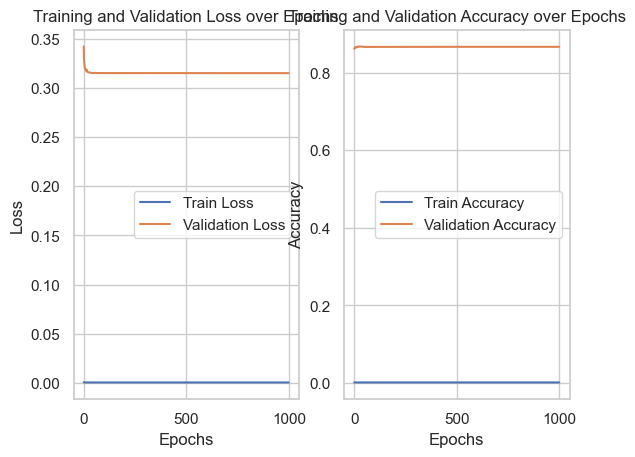

In [114]:
plot_history(history)